**Dataset**
labeled datasset collected from twitter (Lab 1 - Hate Speech.tsv)

**Objective**
classify tweets containing hate speech from other tweets. <br>
0 -> no hate speech <br>
1 -> contains hate speech <br>

**Total Estimated Time = 90-120 Mins**

**Evaluation metric**
macro f1 score

### Import used libraries

In [1]:
import pandas as pd
import re
import contractions
import string
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_colwidth', 500)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt to
[nltk_data]     /home/omargamalelkady/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/omargamalelkady/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/omargamalelkady/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### Load Dataset

###### Note: search how to load the data from tsv file

In [2]:
df = pd.read_csv("Lab 1 - Hate Speech.tsv", sep= "\t")
df.head(100)

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction. #run
1,2,0,@user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx. #disapointed #getthanked
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in urð±!!! ðððð ð¦ð¦ð¦
4,5,0,factsguide: society now #motivation
5,6,0,[2/2] huge fan fare and big talking before they leave. chaos and pay disputes when they get there. #allshowandnogo
6,7,0,@user camping tomorrow @user @user @user @user @user @user @user dannyâ¦
7,8,0,the next school year is the year for exams.ð¯ can't think about that ð­ #school #exams #hate #imagine #actorslife #revolutionschool #girl
8,9,0,we won!!! love the land!!! #allin #cavs #champions #cleveland #clevelandcavaliers â¦
9,10,0,@user @user welcome here ! i'm it's so #gr8 !


### Data splitting

It is a good practice to split the data before EDA helps maintain the integrity of the machine learning process, prevents data leakage, simulates real-world scenarios more accurately, and ensures reliable model performance evaluation on unseen data.

In [3]:
X = df['tweet']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (25228,)
X_test shape: (6307,)
y_train shape: (25228,)
y_test shape: (6307,)


**Observations:**
- Training set: 25,228 samples (80%)
- Testing set: 6,307 samples (20%)
- Used `stratify=y` to preserve the class distribution in both splits

### EDA on training data

- check NaNs

In [4]:
print("NAN values in X_train:", X_train.isnull().sum())
print("NAN values in y_train:", y_train.isnull().sum())

NAN values in X_train: 0
NAN values in y_train: 0


**NaN Check:** No missing values found in X_train or y_train. So no handling needed.

- check duplicates

In [5]:
?X_train.duplicated?

Signature: X_train.duplicated(keep: 'DropKeep' = 'first') -> 'Series'
Docstring:
Indicate duplicate Series values.

Duplicated values are indicated as ``True`` values in the resulting
Series. Either all duplicates, all except the first or all except the
last occurrence of duplicates can be indicated.

Parameters
----------
keep : {'first', 'last', False}, default 'first'
    Method to handle dropping duplicates:

    - 'first' : Mark duplicates as ``True`` except for the first
      occurrence.
    - 'last' : Mark duplicates as ``True`` except for the last
      occurrence.
    - ``False`` : Mark all duplicates as ``True``.

Returns
-------
Series[bool]
    Series indicating whether each value has occurred in the
    preceding values.

See Also
--------
Index.duplicated : Equivalent method on pandas.Index.
DataFrame.duplicated : Equivalent method on pandas.DataFrame.
Series.drop_duplicates : Remove duplicate values from Series.

Examples
--------
By default, for each set of duplicated 

In [6]:
print("Number of duplicate tweets in X_train: ", X_train.duplicated().sum())
print("-" * 50)
print("Duplicate examples in X_train and y_train:")
duplicates = X_train[X_train.duplicated(keep=False)]
print(pd.concat([duplicates, y_train[duplicates.index]], axis=1).head(10))
print("-" * 50)
X_train = X_train.drop_duplicates()
y_train = y_train[X_train.index]
print("After dropping duplicates:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

Number of duplicate tweets in X_train:  1795
--------------------------------------------------
Duplicate examples in X_train and y_train:
                                                                                                               tweet  \
21425   #rainbowrowell   bull up: you will dominate your bull and you will direct it whatever you want it to do. whe   
18766                                                                   i am adventure. #i_am #positive #affirmation   
9215   mrrat395:   #starfightersaturday phantomaviation cptplanespotter blackmaverick12 wbruchal ufeellucky spad5â¦   
754                                                         life is what you make it. letâs make it  ! #motivation   
5595                            #model   i love u take with u all the time in urð±!!! ððððð¦ð¦ð¦   
26418                                                   foods for #healing your body!!    #doplants! #healthy is  !!   
24156                

- show a representative sample of data texts to find out required preprocessing steps

**Duplicates Check:** Found 1,795 duplicate tweets in training data. Dropped them to avoid bias. Training set reduced from 25,228 to 23,433 samples.

In [7]:
print("Random sample of tweets from X_train:")
print(X_train.sample(20))
print("-" * 50)

Random sample of tweets from X_train:
22615                        from elementary school until now â¤ï¸ð©âð©âð§   #nationalbestfriendday
17533                  a giant version of the #flag of #rebellion #sedition and  flapping in #virginia on i-95n
28059                                                      siestas #morrocotudas #iscle somdecamp #luisito  â¦
28848                                                      i am thankful for peanut butter. #thankful #positive
20905                                      @user @user i have twice they've read my emails but not yet answered
4983                                thrilled to win.   #inspired #berkshire #maidenhead #rbwm @user @user @user
30868     heading to galway now for #stalab #demoday @user &amp; tomorrow @user in limerick #ireland #staupland
9688                      looking forward @user to a podium finish @user this year. what's your view?   #gogogo
1330                        feelin a lil down :( #papaya #healthy 

In [8]:
print("Sample of non-hate speech tweets (label=0):")
print(X_train[y_train == 0].sample(10))
print("-"*50)
print("Sample of hate speech tweets (label=1):")
print(X_train[y_train == 1].sample(10))
print("-"*50)

Sample of non-hate speech tweets (label=0):
14657                                                                              #can #good#mood#staff#pay @ torba suit otel
18885    ð  : dog-fighting advocate and all-around jackass #steveking just won the iowa gop primary . ð  #enddogfighting
15071          when does a monday become a an awesome-day? when #deadpool comes through your door, that's when ð #marvel   
12203                                                                                                    @user is @user gone?!
26392                                               to be at #jack bar #chelsea #loving this city and her majesty ððð
458       thinking maybe i should have bought @user instead of @user   #gettingold #becomingboring #notborderlands #goblizzard
29359            @user smile everyone ... we've made it to friyay ððððð #friyay #friday #smile   #epcot #itaâ¦
15980                                                              

In [9]:
print("@user mentions in X_train:")
print(X_train[X_train.str.contains("@")].sample(10))

print('-' * 50)

print("Hashtags in X_train:")
print(X_train[X_train.str.contains("#")].sample(10))

@user mentions in X_train:
502                                                             @user  #ë¤ì´ì_ê·¸ê¸¸ìì_ì¤í¸ë¦¬ë° #ê·¸ê¸¸ìì #ì°ìµì   ending
1465                                                                    @user #countdown only 1 hour left till @user exciting announcement !!
13899                                @user #mtleconte #lecontelodge #rainbowfalls #hottie #peace  ðâï¸ @ rainbow falls, great smokyâ¦ 
29285                                                             @user chips, sunshine and the fabulous garden @user = a perfect wednesday  
11066      @user staed #100daysofcode today and decided to focus on r for cool #datamining &amp;  #datavisualization projects :-) @user @user
6943     the news media has become pathetic.  repoing on things that matter to humans as a species has disappeared. just @user seems to know.
24971                               off to @user this evening to catch @user and @user in love and pasties, miss s direct

**Pattern Analysis — @user mentions & hashtags:**
- Many tweets contain `@user` mentions — these carry no useful meaning for classification and should be removed
- Hashtags like `#maga`, `#tcot`, `#orlando` are common — we should remove the `#` symbol but we will keep the text as it may carry sentiment

In [10]:
url_pattern = r'https?://\S+|www\.\S+'
print("URLs in X_train:")
try: print(X_train[X_train.str.contains(url_pattern, regex=True)].sample(10))
except: print("No URLs found in the sample.")

print('-' * 50)

special_char_pattern = r'[^\w\s*#@]'
print("Special characters in X_train:")
print(X_train[X_train.str.contains(special_char_pattern, regex=True)].sample(10))

URLs in X_train:
No URLs found in the sample.
--------------------------------------------------
Special characters in X_train:
8509                                                                          @user    #fathersday gift for proud dads.available for 1 day
29726                                             @user make #quitting #cigarettes a #gift to yourself and your loved ones.   #fathersday!
11750                                        @user #supreme #erotic #tantric #massage #london is waiting for you with a  #ending massage .
1962     i have resurrected from the twitter dead. i am back guys! and conveniently in time for the euros! #euro2016 #europaleaguefinal  !
20890                        smile more. smiling can make you and others happy.  roy t. bennett #inspiration #quote  #quote #inspirational
8319                              happy weekend! #yoga #sea #yogaeverydamnday #yogi   #life #yogalove #lifestyle #romania p#weekend #beach
24842                          @user #

**Pattern Analysis — URLs & special characters:**
- No URLs found in the dataset
- Special characters are present and should be removed

In [11]:
number_pattern = r'\d+'
print("Numbers in X_train:")
print(X_train[X_train.str.contains(number_pattern, regex=True)].sample(10))

print('-' * 50)

whitespace_pattern = r'\s{2,}'
print("Extra whitespace in X_train:")
print(X_train[X_train.str.contains(whitespace_pattern, regex=True)].sample(10))

Numbers in X_train:
20782                         left leg of the injured tooise replaced with a sliding door wheel.he runs faster than other 49 mates#toi #pet
22844                      rachelpeaches1: while we say #yestoinec ...lets we save dis geh from been a 'corpse' be4 her tym..   #kentuckâ¦
18443                        1 hour to go until our music video is released! #music   #edinburgh #scotland #band @user #musicvideo #a @user
14663                                               thinking of dad's thanks for all that you do#6150  father's day @user @user @user @user
11603                                                  â #gbp/jpy surge pass 151.00 level after uk jobs repo   #blog #silver #gold #forex
25646                                        @user @user @user @user @user @user it is   2 think even 1 died (black muslim etc) 4 #trumpâ¦
30710                                                                      @user  #bihday @user #nowplaying @user - livin'thing #1976 tunes


**Pattern Analysis — Numbers & whitespace:**
- Numbers are present in tweets — they add no value for hate speech detection
- Extra whitespace found between words — should be normalized to single spaces

- check dataset balancing

Number of samples in each class:
label
0    21833
1     1600
Name: count, dtype: int64
--------------------------------------------------
Percentage of samples in each class:
label
0    0.93172
1    0.06828
Name: proportion, dtype: float64
Bar chart of class distribution:


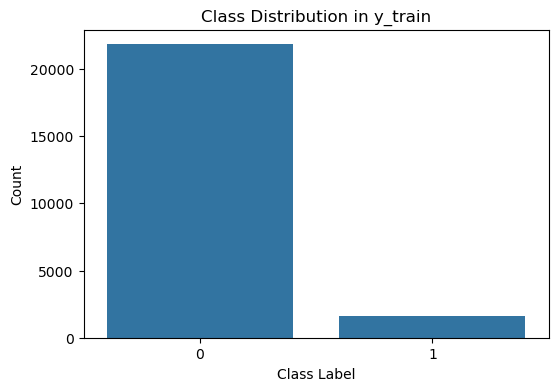

In [12]:
print("Number of samples in each class:")
print(y_train.value_counts())
print('-' * 50)
print("Percentage of samples in each class:")
print(y_train.value_counts(normalize=True))
print("Bar chart of class distribution:")

fig = plt.figure(figsize=(6,4))
sns.countplot(x=y_train)
plt.title("Class Distribution in y_train")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.show()

**Class Balance:** The dataset is heavily imbalanced — 93% non-hate speech vs 7% hate speech.

- Cleaning and Preprocessing are:
    - 1. Apply Contractions 
    - 2. Lowercase all text
    - 3. Remove mentions
    - 4. Remove hashtags
    - 5. Remove special characters
    - 6. Remove extra whitespace
    - 7. Remove punctuation
    - 8. Tokenization
    - 9. Remove stopwords
    - 10. Apply lemmatization

### Cleaning and Preprocessing

#### Extra: use custom scikit-learn Transformers

Using custom transformers in scikit-learn provides flexibility, reusability, and control over the data transformation process, allowing you to seamlessly integrate with scikit-learn's pipelines, enabling you to combine multiple preprocessing steps and modeling into a single workflow. This makes your code more modular, readable, and easier to maintain.

##### link: https://www.andrewvillazon.com/custom-scikit-learn-transformers/

#### Example usage:

In [13]:
def clean_tweet(text):
    
    # remove contractions using lib
    text = contractions.fix(text)
    
    # convert to lowercase
    text = text.lower()
    
    # remove @user mentions
    text = re.sub(r'@user', '', text)
    
    # remove hashtags
    text = re.sub(r'#', '', text)
    
    # remove numbers
    text = re.sub(r"\d+", "", text)
    
    # remove special characters and punctuation
    text = re.sub(r'[^\w\s]', '', text)
    
    # remove extra white spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [14]:
def preprocess_tweet(tweet):
    
    # tokenize the cleaned tweet text
    tokens = word_tokenize(tweet)
    
    # remove stop words
    tokens = [token for token in tokens if token not in stop_words]
    # lemmatize the tokens
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    
    return ' '.join(tokens)

In [15]:
class CustomTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return X.apply(clean_tweet).apply(preprocess_tweet)

In [16]:
# Apply preprocessing to X_train and X_test
X_train_clean = X_train.apply(clean_tweet).apply(preprocess_tweet)
print("Preprocessing applied to X_train.")
print(X_train_clean.sample(10))

print("-" * 50)

X_test_clean = X_test.apply(clean_tweet).apply(preprocess_tweet)
print("Preprocessing applied to X_test.")
print(X_test_clean.sample(10))


Preprocessing applied to X_train.
8627             first ultrasound scan tomorrow wait week day today expecting ultrasound pregnant
4691                                                    thankful soul matethankful positive wayne
8022                                                                           one together never
2661                                           siouxfalls bull dominate bull direct whatever want
5077                        ð selfie sunshine mascara smile dublin ireland freckle dublin ireland
28156                                         waiting phone call let know new house ready hurryup
8009     people stop bleeding every complaint real thing happening world orlandonightclubshooting
15495                                                             way whole account trashing girl
28101                                         ootnððnightout lincoln student nurse brunette smile
11501                 else notice suppoers pageant girl year internalize female oppr

**Preprocessing Applied:** Both `clean_tweet` (contractions, lowercase, remove @user, hashtags, numbers, special chars, whitespace) and `preprocess_tweet` (tokenize, remove stopwords, lemmatize) applied to X_train and X_test.

### Post-Cleaning Visualizations

- Word Cloud per class

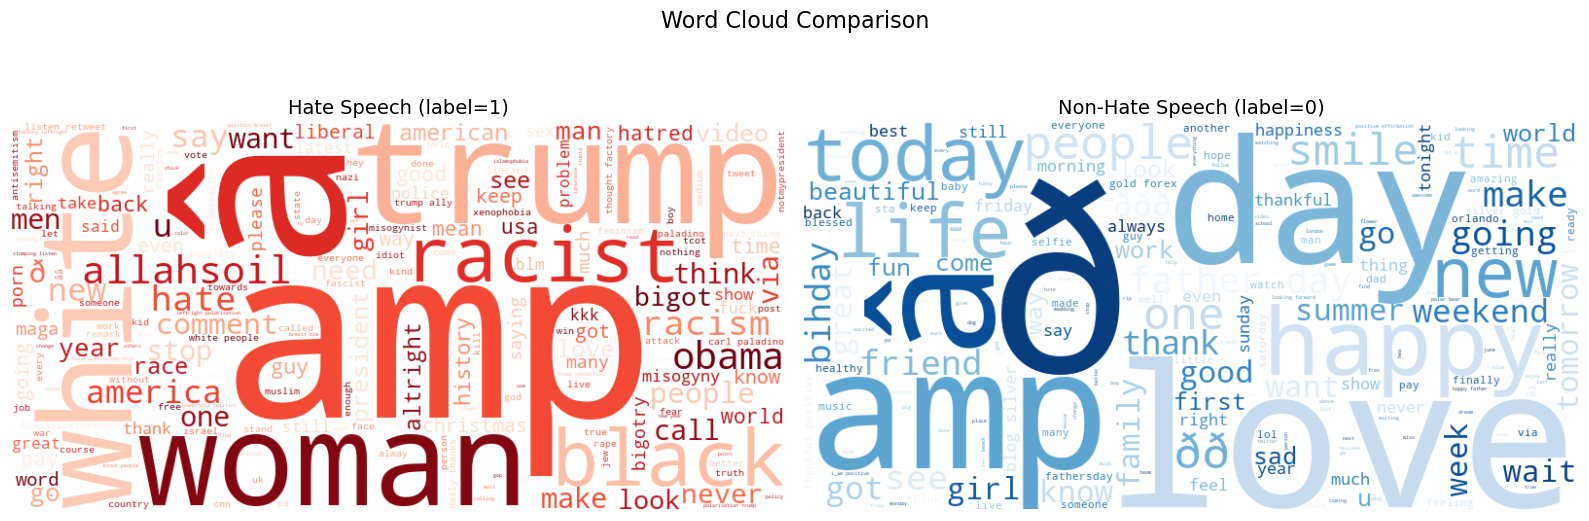

In [17]:
from wordcloud import WordCloud

hate_text = ' '.join(X_train_clean[y_train == 1])
non_hate_text = ' '.join(X_train_clean[y_train == 0])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_hate = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(hate_text)
axes[0].imshow(wc_hate, interpolation='bilinear')
axes[0].set_title('Hate Speech (label=1)', fontsize=14)
axes[0].axis('off')

wc_non_hate = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(non_hate_text)
axes[1].imshow(wc_non_hate, interpolation='bilinear')
axes[1].set_title('Non-Hate Speech (label=0)', fontsize=14)
axes[1].axis('off')

plt.suptitle('Word Cloud Comparison', fontsize=16)
plt.tight_layout()
plt.show()

**Word Cloud summary:** The word clouds clearly show a contrast between the two classes — hate speech is dominated by identity-related and political terms (`trump`, `white`, `black`, `racist`, `woman`, `obama`), while non-hate speech is filled with positive and casual words (`love`, `happy`, `day`, `smile`, `life`).

- Top 20 Most Frequent Words per class

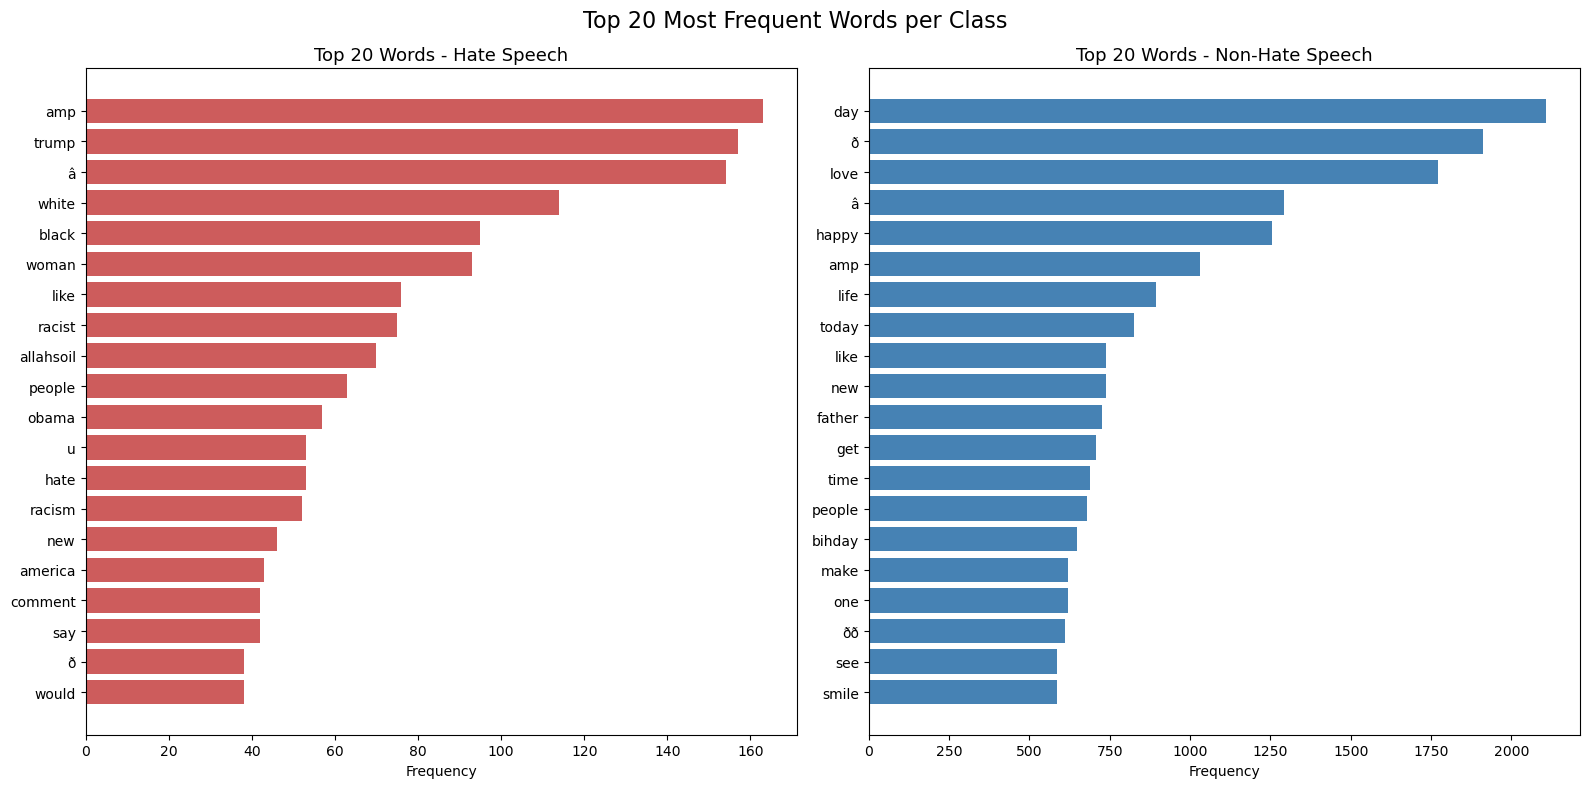

In [18]:
from collections import Counter

hate_words = ' '.join(X_train_clean[y_train == 1]).split()
non_hate_words = ' '.join(X_train_clean[y_train == 0]).split()

top_hate = Counter(hate_words).most_common(20)
top_non_hate = Counter(non_hate_words).most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh([w for w, c in top_hate][::-1], [c for w, c in top_hate][::-1], color='indianred')
axes[0].set_title('Top 20 Words - Hate Speech', fontsize=13)
axes[0].set_xlabel('Frequency')

axes[1].barh([w for w, c in top_non_hate][::-1], [c for w, c in top_non_hate][::-1], color='steelblue')
axes[1].set_title('Top 20 Words - Non-Hate Speech', fontsize=13)
axes[1].set_xlabel('Frequency')

plt.suptitle('Top 20 Most Frequent Words per Class', fontsize=16)
plt.tight_layout()
plt.show()

Hate speech tweets are dominated by politically and racially charged words like `trump`, `white`, `black`, `racist`, `obama`, `hate`, and `racism`. Non-hate speech tweets lean toward positive, everyday language like `love`, `happy`, `smile`, `day`, and `life`. Words like `amp` and `people` appear in both classes but with very different frequencies.

- Median Tweet Length per Class

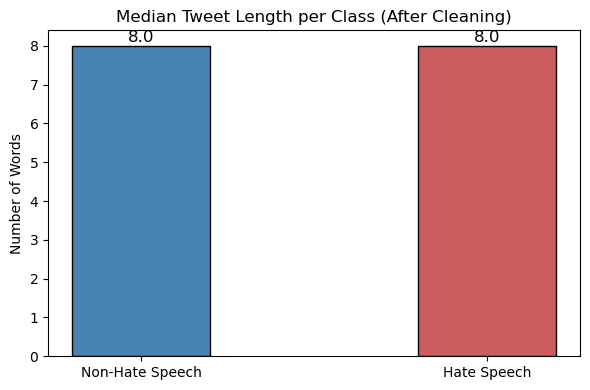

In [19]:
hate_lengths = X_train_clean[y_train == 1].apply(lambda x: len(x.split()))
non_hate_lengths = X_train_clean[y_train == 0].apply(lambda x: len(x.split()))

classes = ['Non-Hate Speech', 'Hate Speech']
medians = [non_hate_lengths.median(), hate_lengths.median()]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(classes, medians, color=['steelblue', 'indianred'], edgecolor='black', width=0.4)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{bar.get_height():.1f}', ha='center', fontsize=12)

ax.set_ylabel('Number of Words')
ax.set_title('Median Tweet Length per Class (After Cleaning)')
plt.tight_layout()
plt.show()

Both classes have the same median tweet length of 8 words after cleaning, indicating that tweet length is not a distinguishing feature between hate and non-hate speech.

In [20]:
bow_vectorizer = CountVectorizer()

X_train_vec = bow_vectorizer.fit_transform(X_train_clean)
X_test_vec = bow_vectorizer.transform(X_test_clean)
print("Shape of X_train_vec:", X_train_vec.shape)
print("Shape of X_test_vec:", X_test_vec.shape)

Shape of X_train_vec: (23433, 35122)
Shape of X_test_vec: (6307, 35122)


**Vectorization:** Used Bag of Words (`CountVectorizer`) to convert cleaned text into numerical features. Fitted on training data only, then transformed both train and test sets.

**You  are doing Great so far!**

### Modelling

#### Extra: use scikit-learn pipline

##### link: https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html

Using pipelines in scikit-learn promotes better code organization, reproducibility, and efficiency in machine learning workflows.

#### Example usage:

In [21]:
model = LogisticRegression(class_weight='balanced', random_state=42)

# Create the pipeline
pipeline_lr = Pipeline(steps=[
    ('preprocessing', CustomTransformer()),
    ('Vectorizing', bow_vectorizer),
    ('model', model),
])


pipeline_lr.fit(X_train, y_train)
y_pred = pipeline_lr.predict(X_test)
print("Predictions on X_test:", y_pred)

Predictions on X_test: [0 0 1 ... 0 0 0]


#### Evaluation

**Evaluation metric:**
macro f1 score

Macro F1 score is a useful metric in scenarios where you want to evaluate the overall performance of a multi-class classification model, **particularly when the classes are imbalanced**

![Calculation](https://assets-global.website-files.com/5d7b77b063a9066d83e1209c/639c3d934e82c1195cdf3c60_macro-f1.webp)

In [22]:
f1 = f1_score(y_test, y_pred, average='macro')
print(f"Macro F1 Score: {f1:.4f}")

Macro F1 Score: 0.8341


**Baseline Evaluation:** Macro F1 score of ~0.82 using BoW + LogisticRegression with `class_weight='balanced'`. The model performs well on non-hate speech but struggles more with the minority hate speech class, which is expected given the heavy class imbalance.

In [23]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Hate Speech', 'Hate Speech']))


Classification Report:
                 precision    recall  f1-score   support

Non-Hate Speech       0.98      0.97      0.97      5864
    Hate Speech       0.65      0.74      0.69       443

       accuracy                           0.95      6307
      macro avg       0.81      0.86      0.83      6307
   weighted avg       0.96      0.95      0.96      6307



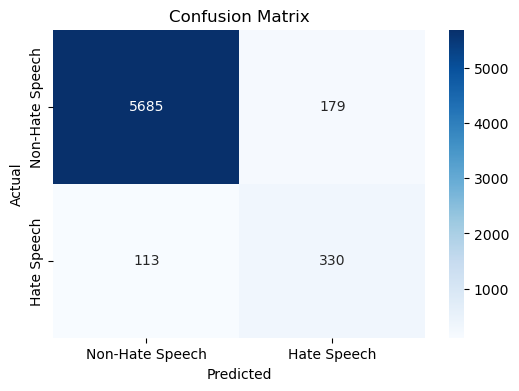

In [24]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Hate Speech', 'Hate Speech'], yticklabels=['Non-Hate Speech', 'Hate Speech'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#### Model Interpretation using eli5

In [25]:
import eli5

eli5.show_weights(pipeline_lr.named_steps['model'], 
                  feature_names=pipeline_lr.named_steps['Vectorizing'].get_feature_names_out().tolist(),
                  top=20)

2026-04-02 15:09:47.104640: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-02 15:09:47.140989: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-02 15:09:48.001139: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Weight?,Feature
+4.802,allahsoil
+3.862,racism
+3.510,bigot
+3.018,blacklivesmatter
+3.018,misogyny
+3.012,pornstars
+2.979,white
+2.944,racist
+2.930,equality
+2.902,misogynist


eli5 reveals the most influential words for each class. Words with high **positive weights** (green) push predictions toward hate speech — these include racially and politically charged terms. Words with high **negative weights** (red) push toward non-hate speech — typically positive or neutral everyday words.

##### Explain individual predictions

In [26]:
# Show explanation for a sample hate speech prediction
sample_hate = X_test[y_test == 1].sample(1, random_state=42)
print("Tweet:", sample_hate.values[0])

sample_cleaned = sample_hate.apply(clean_tweet).apply(preprocess_tweet)
sample_vec = bow_vectorizer.transform(sample_cleaned)

eli5.show_prediction(pipeline_lr.named_steps['model'], 
                     sample_vec, 
                     feature_names=pipeline_lr.named_steps['Vectorizing'].get_feature_names_out().tolist(),
                     top=10)

Tweet: @user #allahsoil if the fear mongers become the loudest voices, who knows what could happen.  â¦â¦ 


### Enhancement

- Using different N-grams
- Using different text representation technique
- Hyperparameter tuning

In [27]:
from sklearn.model_selection import GridSearchCV

pipeline_bow = Pipeline(steps=[
    ('preprocessing', CustomTransformer()),
    ('Vectorizing', CountVectorizer()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42)),
])

param_grid_bow = {
    'Vectorizing__ngram_range': [(1, 1), (1, 2), (1, 3)]
    }

grid_bow = GridSearchCV(pipeline_bow, param_grid_bow, scoring='f1_macro', cv=3, verbose=1)
grid_bow.fit(X_train, y_train)

print("Best params (BoW):", grid_bow.best_params_)
print("Best Macro F1 (BoW CV):", f"{grid_bow.best_score_:.4f}")

y_pred_bow = grid_bow.predict(X_test)
print("Test Macro F1 (BoW):", f"{f1_score(y_test, y_pred_bow, average='macro'):.4f}")

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best params (BoW): {'Vectorizing__ngram_range': (1, 2)}
Best Macro F1 (BoW CV): 0.8066
Test Macro F1 (BoW): 0.8486


Classification Report (BoW):
                 precision    recall  f1-score   support

Non-Hate Speech       0.97      0.99      0.98      5864
    Hate Speech       0.80      0.65      0.72       443

       accuracy                           0.96      6307
      macro avg       0.89      0.82      0.85      6307
   weighted avg       0.96      0.96      0.96      6307



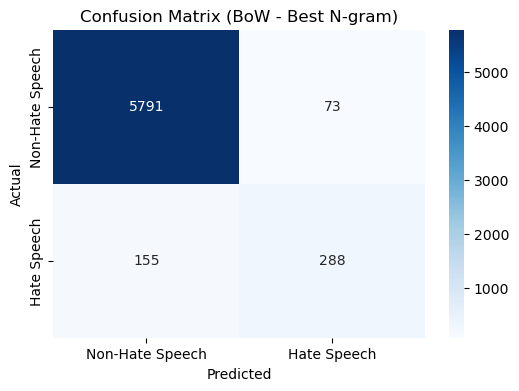

In [28]:
print("Classification Report (BoW):")
print(classification_report(y_test, y_pred_bow, target_names=['Non-Hate Speech', 'Hate Speech']))

cm_bow = confusion_matrix(y_test, y_pred_bow)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_bow, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Hate Speech', 'Hate Speech'], yticklabels=['Non-Hate Speech', 'Hate Speech'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (BoW - Best N-gram)')
plt.show()

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

pipeline_tfidf = Pipeline(steps=[
    ('preprocessing', CustomTransformer()),
    ('Vectorizing', TfidfVectorizer()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42)),
])

param_grid_tfidf = {
    'Vectorizing__ngram_range': [(1, 1), (1, 2), (1, 3)],
}

grid_tfidf = GridSearchCV(pipeline_tfidf, param_grid_tfidf, scoring='f1_macro', cv=3, verbose=1)
grid_tfidf.fit(X_train, y_train)

print("Best params (TF-IDF):", grid_tfidf.best_params_)
print("Best Macro F1 (TF-IDF CV):", f"{grid_tfidf.best_score_:.4f}")

y_pred_tfidf = grid_tfidf.predict(X_test)
print("Test Macro F1 (TF-IDF):", f"{f1_score(y_test, y_pred_tfidf, average='macro'):.4f}")

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best params (TF-IDF): {'Vectorizing__ngram_range': (1, 2)}
Best Macro F1 (TF-IDF CV): 0.7935
Test Macro F1 (TF-IDF): 0.8325


Classification Report (TF-IDF):
                 precision    recall  f1-score   support

Non-Hate Speech       0.98      0.96      0.97      5864
    Hate Speech       0.62      0.78      0.69       443

       accuracy                           0.95      6307
      macro avg       0.80      0.87      0.83      6307
   weighted avg       0.96      0.95      0.95      6307



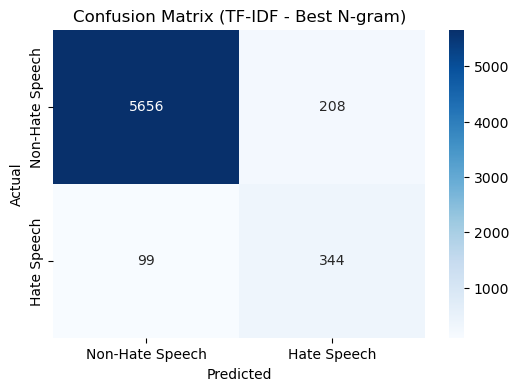

In [30]:
print("Classification Report (TF-IDF):")
print(classification_report(y_test, y_pred_tfidf, target_names=['Non-Hate Speech', 'Hate Speech']))

cm_tfidf = confusion_matrix(y_test, y_pred_tfidf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Hate Speech', 'Hate Speech'], yticklabels=['Non-Hate Speech', 'Hate Speech'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (TF-IDF - Best N-gram)')
plt.show()

In [31]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

pipeline_smote = ImbPipeline(steps=[
    ('preprocessing', CustomTransformer()),
    ('Vectorizing', CountVectorizer()),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(class_weight='balanced', random_state=42)),
])

pipeline_smote.fit(X_train, y_train)
y_pred_smote = pipeline_smote.predict(X_test)

f1_smote = f1_score(y_test, y_pred_smote, average='macro')
print(f"Macro F1 Score with SMOTE: {f1_smote:.4f}")

Macro F1 Score with SMOTE: 0.6933


Classification Report (SMOTE):
                 precision    recall  f1-score   support

Non-Hate Speech       0.97      0.90      0.94      5864
    Hate Speech       0.34      0.67      0.45       443

       accuracy                           0.89      6307
      macro avg       0.66      0.79      0.69      6307
   weighted avg       0.93      0.89      0.90      6307



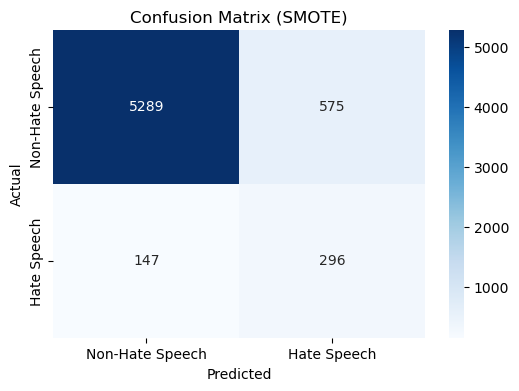

In [32]:
print("Classification Report (SMOTE):")
print(classification_report(y_test, y_pred_smote, target_names=['Non-Hate Speech', 'Hate Speech']))

cm_smote = confusion_matrix(y_test, y_pred_smote)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Hate Speech', 'Hate Speech'], yticklabels=['Non-Hate Speech', 'Hate Speech'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (SMOTE)')
plt.show()

### Conclusion and final results


In [33]:
results = pd.DataFrame({
    'Model': [
        'Baseline (BoW + class_weight)',
        'BoW + GridSearch (best n-gram)',
        'TF-IDF + GridSearch (best n-gram)',
        'SMOTE + BoW',
    ],
    'Macro F1': [
        f1_score(y_test, y_pred, average='macro'),
        f1_score(y_test, y_pred_bow, average='macro'),
        f1_score(y_test, y_pred_tfidf, average='macro'),
        f1_score(y_test, y_pred_smote, average='macro'),
    ]
})

results = results.sort_values('Macro F1', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

                            Model  Macro F1
   BoW + GridSearch (best n-gram)  0.848556
    Baseline (BoW + class_weight)  0.834119
TF-IDF + GridSearch (best n-gram)  0.832518
                      SMOTE + BoW  0.693319


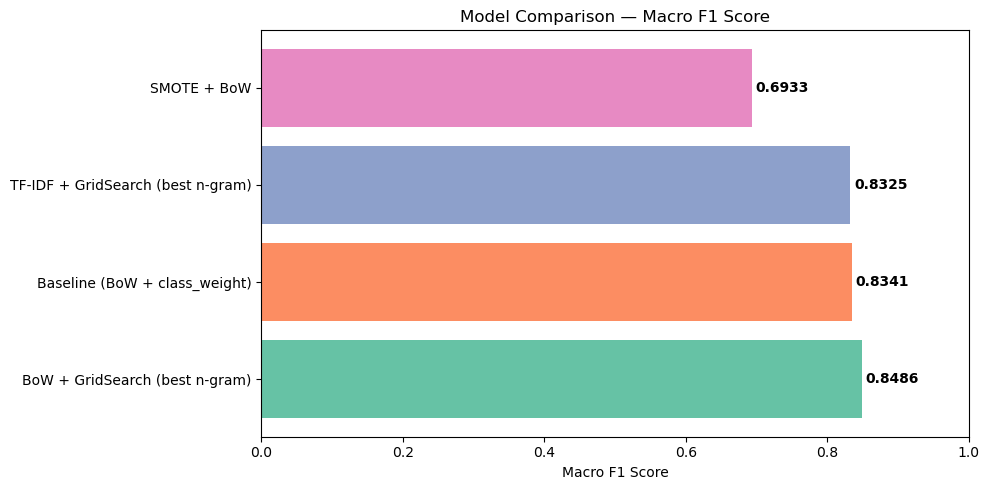


Best model: BoW + GridSearch (best n-gram) with Macro F1 = 0.8486


In [34]:
fig, ax = plt.subplots(figsize=(10, 5))

cmap = plt.cm.Set2
colors = [cmap(i) for i in range(len(results))]
bars = ax.barh(results['Model'], results['Macro F1'], color=colors)

for bar, score in zip(bars, results['Macro F1']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, 
            f'{score:.4f}', va='center', fontweight='bold')

ax.set_xlabel('Macro F1 Score')
ax.set_title('Model Comparison — Macro F1 Score')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

print(f"\nBest model: {results.iloc[0]['Model']} with Macro F1 = {results.iloc[0]['Macro F1']:.4f}")

**Final Conclusion:** We compared 4 approaches — baseline BoW with class weights, BoW with GridSearch on n-grams, TF-IDF with GridSearch on n-grams, and SMOTE oversampling. The bar chart above shows the best performing model.:
- `class_weight='balanced'` was crucial for handling the 93/7 class imbalance
- N-gram tuning via GridSearch helped capture multi-word hate speech patterns
- The hate speech class remains the harder class to predict due to its small size and ambiguous language

#### Done!